In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split #split the data into training and testing sets
from sklearn.preprocessing import StandardScaler    #converts everything to same scale
from sklearn.linear_model import LogisticRegression # despite the name, it does CLASSIFICATION not regression
from sklearn.ensemble import RandomForestClassifier  # MAIN model (stronger, more accurate)
from sklearn.metrics import classification_report, confusion_matrix #tools to measure how good our model is
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/telco_churn_processed.csv")

print("Shape:", df.shape)
print("Churn distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 34)
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
# X = input features (everything the model learns FROM)
# y = target (what the model tries to PREDICT)

X = df.drop('Churn', axis=1)  # everything except Churn
y = df['Churn']                # only Churn column

print("X shape (features):", X.shape)
print("y shape (target):", y.shape)
print("\nSample of X:")
print(X.head(3))
print("\nSample of y:")
print(y.head(3))

X shape (features): (7043, 33)
y shape (target): (7043,)

Sample of X:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  \
0                 1           29.85         29.85   
1                 0           56.95       1889.50   
2                 1           53.85        108.15   

   MultipleLines_No phone service  ...  StreamingMovies_No internet service  \
0                            True  ...                                False   
1                           False  ...                                False   
2                           False  ...                                False   

   StreamingMovies_Yes  Contract_One year  Contract_Two year  \
0                False              False         

In [4]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to test set
    random_state=42,    # fixed seed = same split every time
    stratify=y          # keep same churn ratio in both sets
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nChurn ratio in training:")
print(y_train.value_counts(normalize=True))
print("\nChurn ratio in testing:")
print(y_test.value_counts(normalize=True))

Training set size: (5634, 33)
Testing set size: (1409, 33)

Churn ratio in training:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Churn ratio in testing:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# IMPORTANT: fit ONLY on training data, then transform both     #always fit on train data, never on test data (to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - tenure range:")
print(f"  Min: {X_train['tenure'].min()}, Max: {X_train['tenure'].max()}")

print("\nAfter scaling - tenure range:")
print(f"  Min: {X_train_scaled[:, 0].min():.2f}, "
      f"Max: {X_train_scaled[:, 0].max():.2f}")

Before scaling - tenure range:
  Min: 0, Max: 72

After scaling - tenure range:
  Min: -1.01, Max: 0.99


In [6]:
# BASELINE: Logistic Regression (simple model)
print("=== BASELINE: Logistic Regression ===\n")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
lr_predictions = lr_model.predict(X_test_scaled)

# Evaluate
print(classification_report(y_test, lr_predictions, 
                            target_names=['Stayed', 'Churned']))

=== BASELINE: Logistic Regression ===

              precision    recall  f1-score   support

      Stayed       0.84      0.91      0.87      1035
     Churned       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



PRECISION = "when model says churn, how often is it right?"
→ Churned precision 0.68 = 68% of predicted churners actually churned
→ the other 32% were false alarms (wasted discount offers)

RECALL = "of all actual churners, how many did model catch?"
→ Churned recall 0.53 = only caught 53% of real churners
→ missed 47% — these customers left without us knowing!

F1-SCORE = balance between precision and recall
→ single number combining both
→ use when you care about both

SUPPORT = how many actual cases exist
→ 376 actual churners in test set
→ 1033 actual stayers in test set

REMEMBER FROM PROJECT BRIEF:
→ our goal was 80% Recall on churners
→ 53% is not good enough yet
→ this is why we also build a stronger model


In [7]:
print("=== MAIN MODEL: Random Forest ===\n")

rf_model = RandomForestClassifier(
    n_estimators=100,    # use 100 decision trees
    random_state=42,
    class_weight='balanced'  # handle class imbalance
)

rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

print(classification_report(y_test, rf_predictions,
                            target_names=['Stayed', 'Churned']))

=== MAIN MODEL: Random Forest ===

              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1035
     Churned       0.65      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



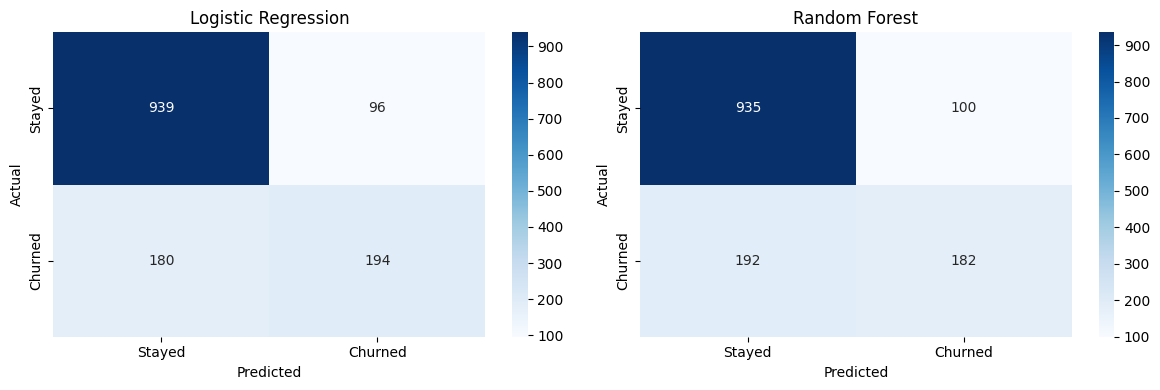

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix for both models
for idx, (model_name, preds) in enumerate([
    ('Logistic Regression', lr_predictions),
    ('Random Forest', rf_predictions)
]):
    cm = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'],
                cmap='Blues')
    
    axes[idx].set_title(f'{model_name}')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

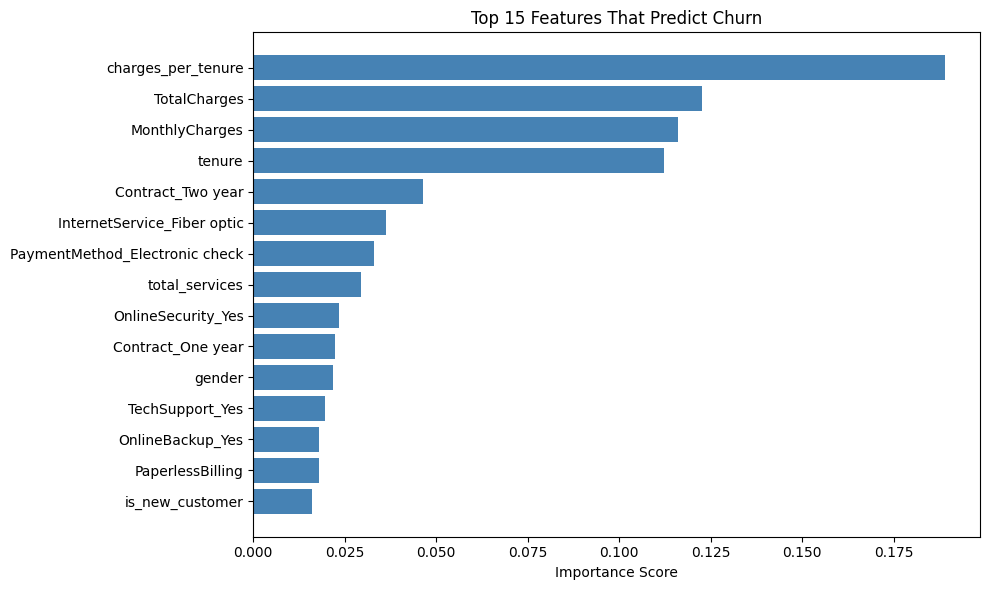


Top 5 most important features:
               feature  importance
30  charges_per_tenure    0.189121
8         TotalCharges    0.122558
7       MonthlyCharges    0.116092
4               tenure    0.112272
26   Contract_Two year    0.046395


In [9]:
# Which features matter most to Random Forest?
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

# Sort by importance, highest first
feature_importance = feature_importance.sort_values(
    'importance', ascending=False
).head(15)  # top 15 only

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], 
         feature_importance['importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Features That Predict Churn')
plt.gca().invert_yaxis()  # most important at top
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feature_importance.head())

charges_per_tenure     ← WE CREATED THIS FEATURE!
→ the feature we engineered ourselves is the most important one 
it didn't exist in the original data  we invented it


In [10]:
# PROBLEM: model is too conservative, missing churners
# FIX: lower the decision threshold
# Default threshold = 0.5 (need 50% confidence to predict churn)
# Lower it = model flags more people as churners = higher recall

from sklearn.metrics import classification_report

# Get PROBABILITIES instead of hard 0/1 predictions
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Try threshold of 0.3 instead of 0.5
# means: "if model is 30% sure someone will churn, flag them"
threshold = 0.3
rf_predictions_tuned = (rf_proba >= threshold).astype(int)

print("=== RANDOM FOREST WITH TUNED THRESHOLD (0.3) ===\n")
print(classification_report(y_test, rf_predictions_tuned,
                            target_names=['Stayed', 'Churned']))

=== RANDOM FOREST WITH TUNED THRESHOLD (0.3) ===

              precision    recall  f1-score   support

      Stayed       0.88      0.76      0.82      1035
     Churned       0.52      0.73      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



   threshold  recall  precision
0       0.10    0.92       0.39
1       0.15    0.88       0.45
2       0.20    0.84       0.48
3       0.25    0.79       0.51
4       0.30    0.72       0.52
5       0.35    0.65       0.55
6       0.40    0.61       0.59
7       0.45    0.55       0.61
8       0.50    0.49       0.65
9       0.55    0.41       0.68


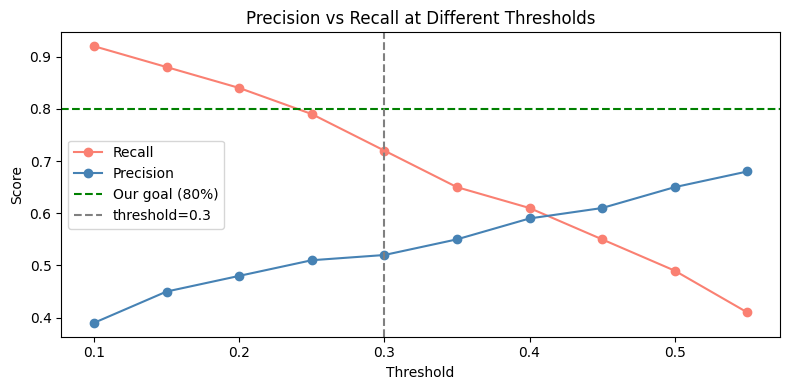

In [11]:
from sklearn.metrics import recall_score, precision_score
import numpy as np

thresholds = np.arange(0.1, 0.6, 0.05)
results = []

for t in thresholds:
    preds = (rf_proba >= t).astype(int)
    recall = recall_score(y_test, preds)
    precision = precision_score(y_test, preds)
    results.append({
        'threshold': round(t, 2),
        'recall': round(recall, 2),
        'precision': round(precision, 2)
    })

results_df = pd.DataFrame(results)
print(results_df)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(results_df['threshold'], results_df['recall'], 
         label='Recall', color='salmon', marker='o')
plt.plot(results_df['threshold'], results_df['precision'], 
         label='Precision', color='steelblue', marker='o')
plt.axhline(y=0.80, color='green', linestyle='--', label='Our goal (80%)')
plt.axvline(x=0.3, color='gray', linestyle='--', label='threshold=0.3')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import joblib
import os

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save the model and scaler
joblib.dump(rf_model, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Save feature names (needed for API later)
feature_names = list(X.columns)
joblib.dump(feature_names, '../models/feature_names.pkl')

print("✅ Model saved!")
print("✅ Scaler saved!")
print("✅ Feature names saved!")
print(f"\nModel expects {len(feature_names)} features")

✅ Model saved!
✅ Scaler saved!
✅ Feature names saved!

Model expects 33 features
